In [ ]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
mushroom = fetch_ucirepo(id=73)

# data (as pandas dataframes)
X = mushroom.data.features
y = mushroom.data.targets

# metadata
print(mushroom.metadata)

# variable information
print(mushroom.variables)

print(X.head())
print("===============")
print(y.head())

{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

In [ ]:
import numpy as np
import pandas as pd

# 1. Преобразование целевой переменной в 0 и 1
y_series = y.iloc[:, 0]
y_binary = y_series.map({'p': 1, 'e': 0})

# 2Случайный отбор признаков
all_features = X.columns
n_features = len(all_features)
n_to_select = int(np.sqrt(n_features))
np.random.seed(552)
selected_features = np.random.choice(all_features, size=n_to_select, replace=False)

X_reduced = X[selected_features].copy()

print("\nОтобранные признаки:", selected_features)
print("\nРазмер нового X:", X_reduced.shape)


Отобранные признаки: ['ring-type' 'gill-color' 'stalk-shape' 'gill-attachment']

Размер нового X: (8124, 4)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_binary, test_size=0.2, random_state=42)

print(f"Обучающая выборка (X_train): {X_train.shape}")
print(f"Тестовая выборка (X_test): {X_test.shape}")

Обучающая выборка (X_train): (6499, 4)
Тестовая выборка (X_test): (1625, 4)


In [ ]:
import numpy as np
import pandas as pd

class Node:
    def __init__(self, attribute=None, prediction=None, prob_1=None):
        self.attribute = attribute
        self.children = {}
        self.prediction = prediction
        self.prob_1 = prob_1

class MushroomTree:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.root = None

    def _entropy(self, y):
        values, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum([p * np.log2(p) for p in probs if p > 0])

    # ищем лучший признак
    def _best_split(self, X, y):
        base_entropy = self._entropy(y)
        best_gain = -1
        best_attr = None

        for attr in X.columns:
            values, counts = np.unique(X[attr], return_counts=True)
            weighted_entropy = 0

            for val, count in zip(values, counts):
                subset_y = y[X[attr] == val]
                weighted_entropy += (count / len(y)) * self._entropy(subset_y)

            gain = base_entropy - weighted_entropy # прирост информации

            if gain > best_gain:
                best_gain = gain
                best_attr = attr

        return best_attr, best_gain

    def _build_tree(self, X, y, depth):
        prob_1 = y.mean() if len(y) > 0 else 0
        prediction = 1 if prob_1 >= 0.5 else 0

        # делаем лист если:
        # - Достигли макс. глубины
        # - Остался только один класс (энтропия 0)
        # - Кончились признаки
        if depth >= self.max_depth or len(np.unique(y)) == 1 or X.shape[1] == 0:
            return Node(prediction=prediction, prob_1=prob_1)

        best_attr, gain = self._best_split(X, y)

        if gain == 0:
            return Node(prediction=prediction, prob_1=prob_1)

        node = Node(attribute=best_attr, prediction=prediction, prob_1=prob_1)

        # создаем ветки
        for val in np.unique(X[best_attr]):
            mask = X[best_attr] == val
            X_subset = X[mask].drop(columns=[best_attr])
            y_subset = y[mask]

            child_node = self._build_tree(X_subset, y_subset, depth + 1)
            node.children[val] = child_node

        return node

    def fit(self, X, y):
        self.root = self._build_tree(X, y, 0)

    def _predict_one(self, node, row):
        if not node.children:
            return node.prediction, node.prob_1

        val = row[node.attribute]

        if val in node.children:
            return self._predict_one(node.children[val], row)
        else:
            return node.prediction, node.prob_1

    def predict(self, X):
        predictions = []
        probabilities = []
        for i in range(len(X)):
            pred, prob = self._predict_one(self.root, X.iloc[i])
            predictions.append(pred)
            probabilities.append(prob)
        return np.array(predictions), np.array(probabilities)


In [ ]:
tree_model = MushroomTree(max_depth=5)

tree_model.fit(X_train, y_train)

y_pred, y_prob = tree_model.predict(X_test)

print("Предсказание:", y_pred[:50])
print("Реальность:  ", y_test.values[:50])

Предсказание: [0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0
 1 1 1 1 0 1 0 1 0 0 0 1 0]
Реальность:   [0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 0 1 0
 1 1 1 1 0 1 0 1 0 1 0 1 0]


In [ ]:
y_true = y_test.values

TP = np.sum((y_pred == 1) & (y_true == 1))
TN = np.sum((y_pred == 0) & (y_true == 0))
FP = np.sum((y_pred == 1) & (y_true == 0))
FN = np.sum((y_pred == 0) & (y_true == 1))

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-10) # Доверие к предсказанию класса "1"
recall = TP / (TP + FN + 1e-10)    # сколько реально ядовитых нашло

print("\n--- Метрики ---")
print(f"Accuracy (Общая точность):  {accuracy:.4f}")
print(f"Precision (Точность):       {precision:.4f}")
print(f"Recall (Полнота):           {recall:.4f}")

TP: 641, TN: 843, FP: 0, FN: 141

--- Метрики ---
Accuracy (Общая точность):  0.9132
Precision (Точность):       1.0000
Recall (Полнота):           0.8197


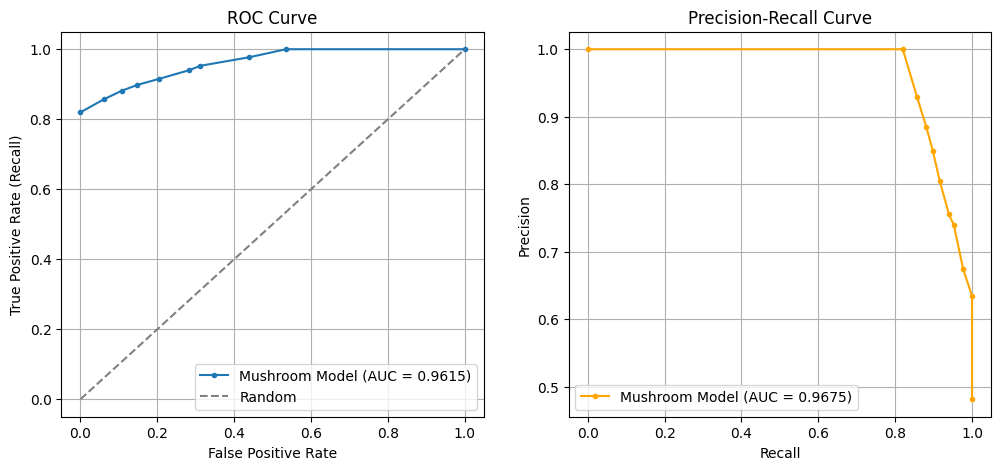

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y_true = y_test.values
probs = y_prob

thresholds = np.sort(np.unique(probs))[::-1]

tpr_list = []
fpr_list = []
precision_list = []

P_total = np.sum(y_true == 1)
N_total = np.sum(y_true == 0)

for thresh in thresholds:
    y_temp_pred = (probs >= thresh).astype(int)

    TP = np.sum((y_temp_pred == 1) & (y_true == 1))
    FP = np.sum((y_temp_pred == 1) & (y_true == 0))

    tpr = TP / P_total
    fpr = FP / N_total

    if (TP + FP) > 0:
        prec = TP / (TP + FP)
    else:
        prec = 1.0

    tpr_list.append(tpr)
    fpr_list.append(fpr)
    precision_list.append(prec)

tpr_arr = np.array(tpr_list)
fpr_arr = np.array(fpr_list)
prec_arr = np.array(precision_list)

roc_order = np.argsort(fpr_arr)
fpr_sorted = fpr_arr[roc_order]
tpr_roc_sorted = tpr_arr[roc_order]
auc_roc = np.trapezoid(tpr_roc_sorted, fpr_sorted)

tpr_pr_with_start = np.concatenate(([0], tpr_arr))
prec_pr_with_start = np.concatenate(([1], prec_arr))

pr_order = np.argsort(tpr_pr_with_start)
tpr_pr_sorted = tpr_pr_with_start[pr_order]
prec_sorted = prec_pr_with_start[pr_order]
auc_pr = np.trapezoid(prec_sorted, tpr_pr_sorted)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_sorted, tpr_roc_sorted, marker='.', label=f'Mushroom Model (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(tpr_pr_sorted, prec_sorted, marker='.', color='orange', label=f'Mushroom Model (AUC = {auc_pr:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()

plt.show()